# COVID-19 case growth: US states and selected countries

Naive, short-term views of case growth from test-confirmed counts: doubling times from exponential fits,
how they changed over time, and testing rates.

Data: COVID Tracking Project (US states) and Johns Hopkins CSSE (countries); see `covid19/data.py`.
`AS_OF` cuts the data at the date this notebook was last updated in 2020; move it to see another point in time
(the data runs to 2021-03-07).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # project root, so covid19 imports without installing
from covid19.data import get_state_df, us_states_daily, world_daily
from covid19.models import doubling_time_in_days, get_state_doubling_df, get_zero_aligned_log_positive, period_factor_plot

AS_OF = "2020-09-23"
LAST_N_DAYS = 10       # days used for "current" doubling times
RESOLUTION_TIME = 10   # days for a case to resolve (recover or die)

df, states_in_order = us_states_daily(as_of=AS_OF)
dfus = get_state_df(df, "*", additional_aggregation_keys=["negative", "pending", "population"])
print(f"US data through {df.date.max():%Y-%m-%d}; states by total cases: {' '.join(states_in_order)}")
dfus.tail()

US data through 2020-09-23; states by total cases: CA TX FL NY GA IL AZ NJ NC TN LA PA AL OH VA SC MI MA MD MO IN WI MS MN WA OK IA AR NV CO UT KY CT KS NE ID OR NM RI PR DE SD ND DC WV HI MT NH AK ME WY GU VT VI MP AS


,date,positive,daily_new_positive,death,daily_new_death,tests,negative,pending,population
250,2020-09-19,6712036.0,45668,191455.0,747,102908256.0,31169829.0,13217.0,331433217.0
251,2020-09-20,6747569.0,35533,191782.0,327,103902528.0,31435785.0,13192.0,331433217.0
252,2020-09-21,6786731.0,39162,192063.0,281,104652879.0,31582537.0,13241.0,331433217.0
253,2020-09-22,6835717.0,48986,192922.0,859,105570092.0,31840636.0,7999.0,331433217.0
254,2020-09-23,6875215.0,39498,194078.0,1156,106583459.0,32064596.0,10535.0,331433217.0


## Zero-day normalized log of total verified covid-19 cases

Each state's log(total cases), shifted so the curves start together on the first day with more than 10 cases.
Flattening slopes show slowing growth. (The "grass" blows over to the right.)

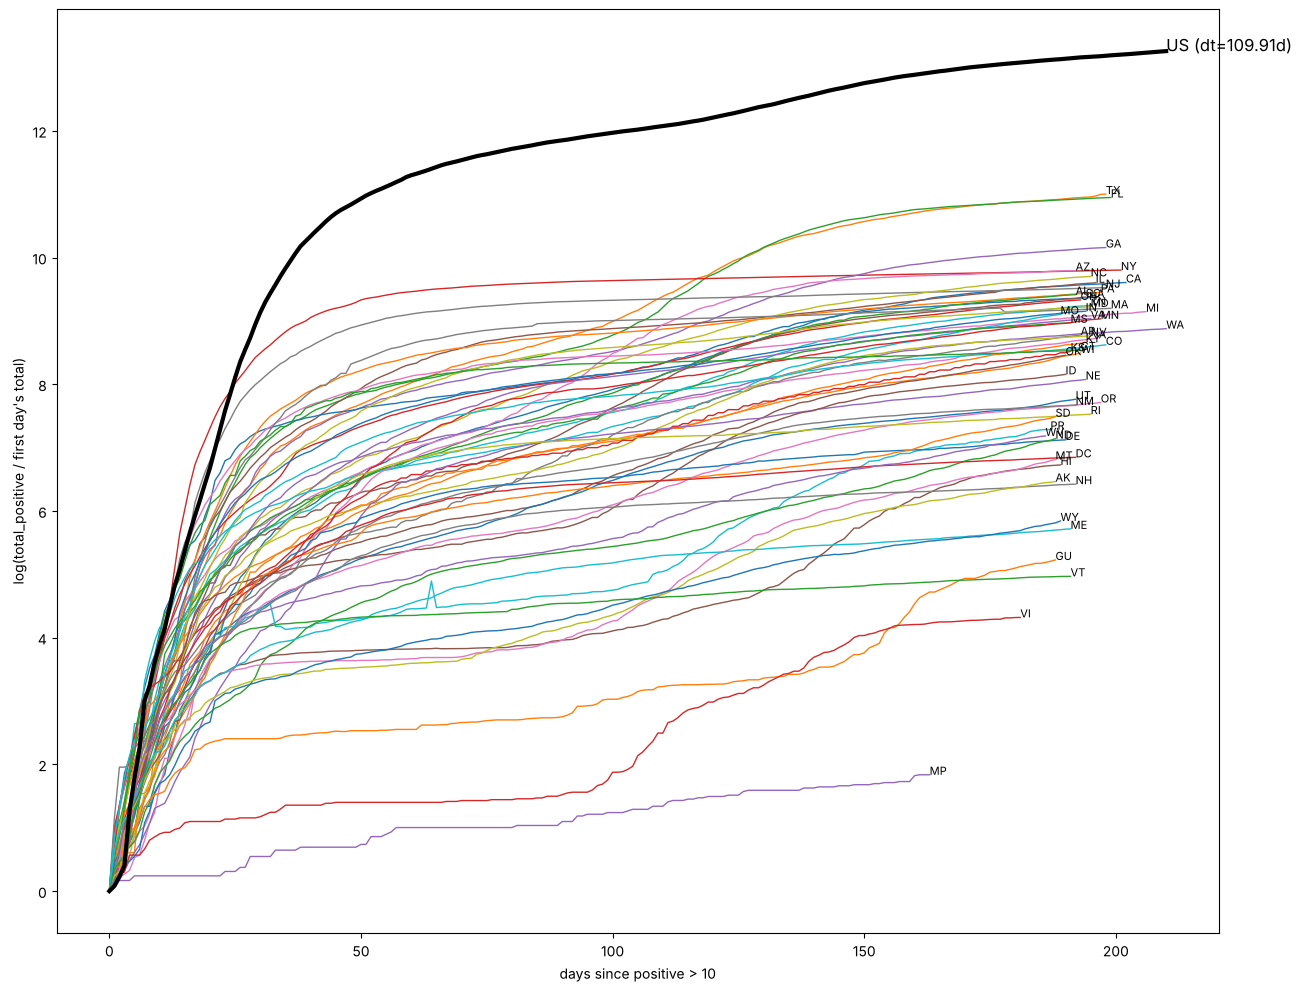

In [2]:
min_pos = 10
key_value = f"days_since_{min_pos}"

fig, ax = plt.subplots(figsize=[15, 12])
for s in states_in_order:
    dfq = get_zero_aligned_log_positive(get_state_df(df, s), min_pos=min_pos)
    if len(dfq):
        ax.plot(dfq[key_value], dfq.log_positive, lw=1)
        ax.annotate(s, (dfq[key_value].values[-1], dfq.log_positive.values[-1]), fontsize=8)

_, dt_us, _ = get_state_doubling_df(df, "*", use_last_n_days=LAST_N_DAYS)
dfq = get_zero_aligned_log_positive(dfus, min_pos=min_pos)
ax.plot(dfq[key_value], dfq.log_positive, "k", lw=3)
ax.annotate(f"US (dt={dt_us:1.2f}d)", (dfq[key_value].values[-1], dfq.log_positive.values[-1]), fontsize=12)
ax.set_xlabel(f"days since positive > {min_pos}")
ax.set_ylabel("log(total_positive / first day's total)")
plt.show()

## US total verified covid-19 cases: current doubling period and its history

Use the last few days to estimate the current doubling period, plotted against the full history for context.
The rolling plots repeat the fit over every 10-day window. Their ratio to the ~10-day resolution time compares
how fast cases are added with how fast they clear: below 1, active cases grow.

US Total Positive, doubling every 109.9 days as of 2020-09-23, based on the last 10 days of data


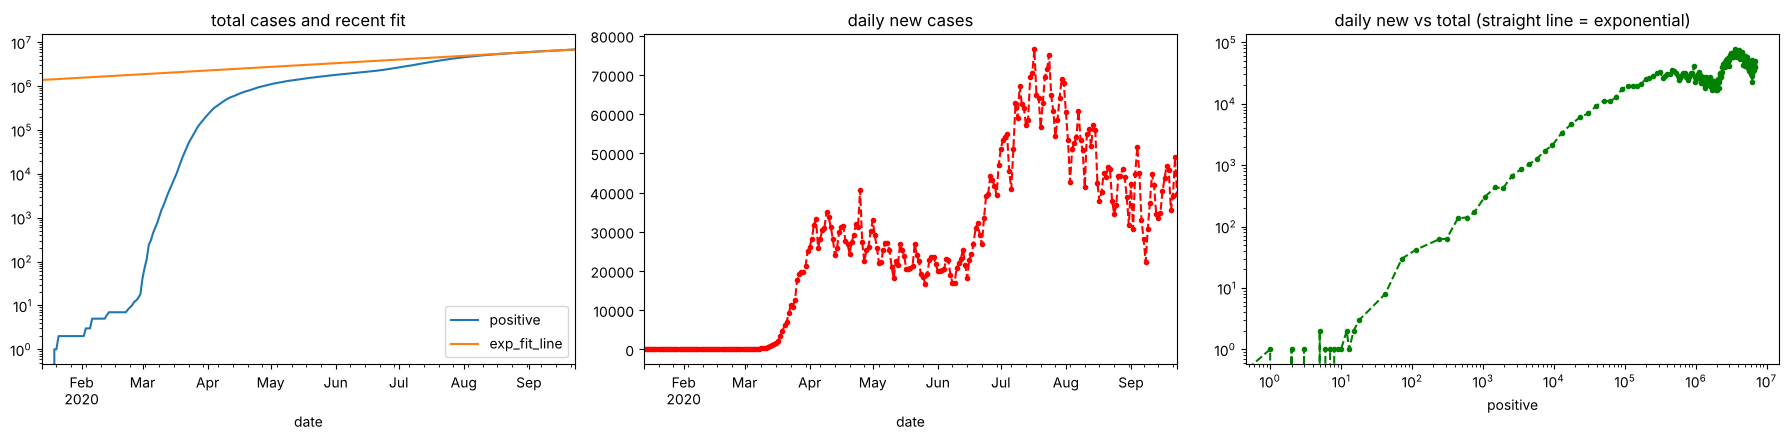

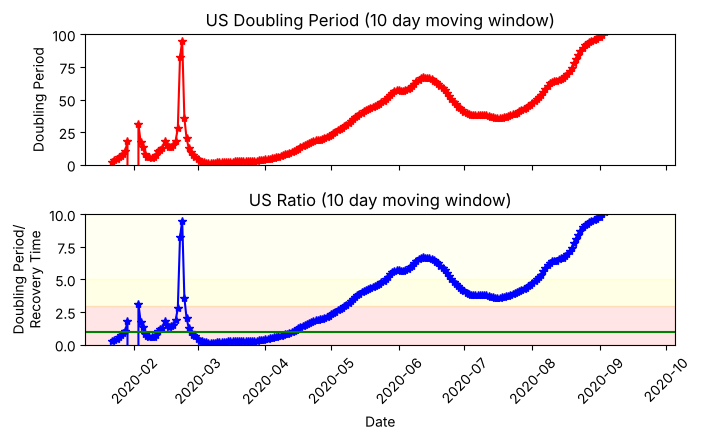

In [3]:
dfa, dt, _ = get_state_doubling_df(df, "*", use_last_n_days=LAST_N_DAYS)
print(f"US Total Positive, doubling every {dt:.1f} days as of {dfa.date.max():%Y-%m-%d}, "
      f"based on the last {LAST_N_DAYS} days of data")

fig, axes = plt.subplots(1, 3, figsize=[18, 4.5])
dfa.plot(x="date", y=["positive", "exp_fit_line"], ax=axes[0], logy=True, title="total cases and recent fit")
dfa.plot(x="date", y="daily_new_positive", ax=axes[1], style=".--r", legend=False, title="daily new cases")
dfa.plot(x="positive", y="daily_new_positive", ax=axes[2], style=".--g", logx=True, logy=True, legend=False,
         title="daily new vs total (straight line = exponential)")
plt.tight_layout()
plt.show()
period_factor_plot(df, "*", ylimit=10)

## Testing data

Test positive rate is the number of covid-19 positive tests over the total number of tests.

Uncertainty in the total number of tests due to the emerging private testing?

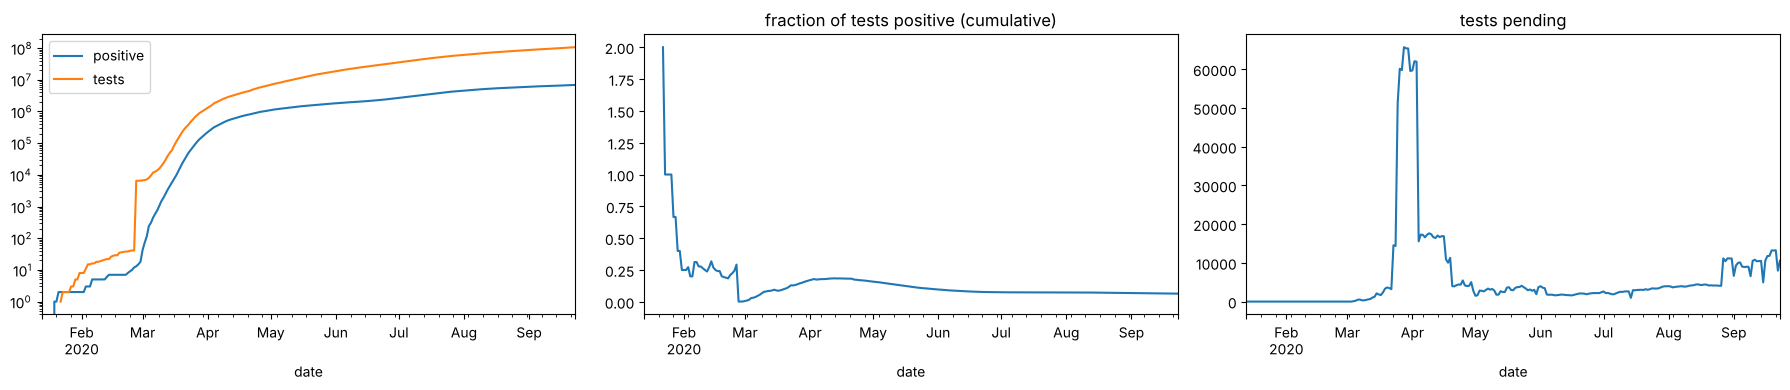

In [4]:
dfus["fraction_positive"] = dfus["positive"] / dfus["tests"]
fig, axes = plt.subplots(1, 3, figsize=[18, 4])
dfus.plot(x="date", y=["positive", "tests"], logy=True, ax=axes[0])
dfus.plot(x="date", y="fraction_positive", ax=axes[1], legend=False, title="fraction of tests positive (cumulative)")
dfus.plot(x="date", y="pending", ax=axes[2], legend=False, title="tests pending")
plt.tight_layout()
plt.show()

## Current measured ratios

These are based on cases that test positive and test negative (state labs policies vary on this).

In [5]:
last = dfus.iloc[-1]
print(f"Positive / total tests:  {last.positive / last.tests:.1%} of {int(last.tests):,} tests tracked")
print(f"Deaths / positive cases: {last.death / last.positive:.1%}")
print(f"Share of population tested at least once (upper bound): {last.tests / last.population:.1%}")

Positive / total tests:  6.5% of 106,583,459 tests tracked
Deaths / positive cases: 2.8%
Share of population tested at least once (upper bound): 32.2%


## State trends and doubling periods

Doubling periods from each state's last 10 days, and every state's total cases with that fit.

In [6]:
rows = []
for s in states_in_order:
    dfq, dt, _ = get_state_doubling_df(df, s, use_last_n_days=LAST_N_DAYS)
    last = dfq.iloc[-1]
    rows.append({"state": s, "positive": int(last.positive), "doubling_days": dt,
                 "fraction_positive": last.positive / last.tests, "fraction_tested": last.tests / last.population})
states = pd.DataFrame(rows).set_index("state")
states.style.format({"positive": "{:,}", "doubling_days": "{:.0f}", "fraction_positive": "{:.1%}",
                     "fraction_tested": "{:.1%}"}, na_rep="–")

,positive,doubling_days,fraction_positive,fraction_tested
state,,,,
CA,"787,470",154,5.7%,35.1%
TX,"719,599",80,11.4%,21.7%
FL,"682,370",170,8.9%,35.7%
NY,"451,892",393,4.5%,52.1%
GA,"309,678",129,11.0%,26.4%
IL,"281,312",101,5.4%,41.3%
AZ,"215,284",190,10.3%,28.7%
NJ,"205,606",276,6.0%,38.6%
NC,"196,501",108,6.9%,27.1%


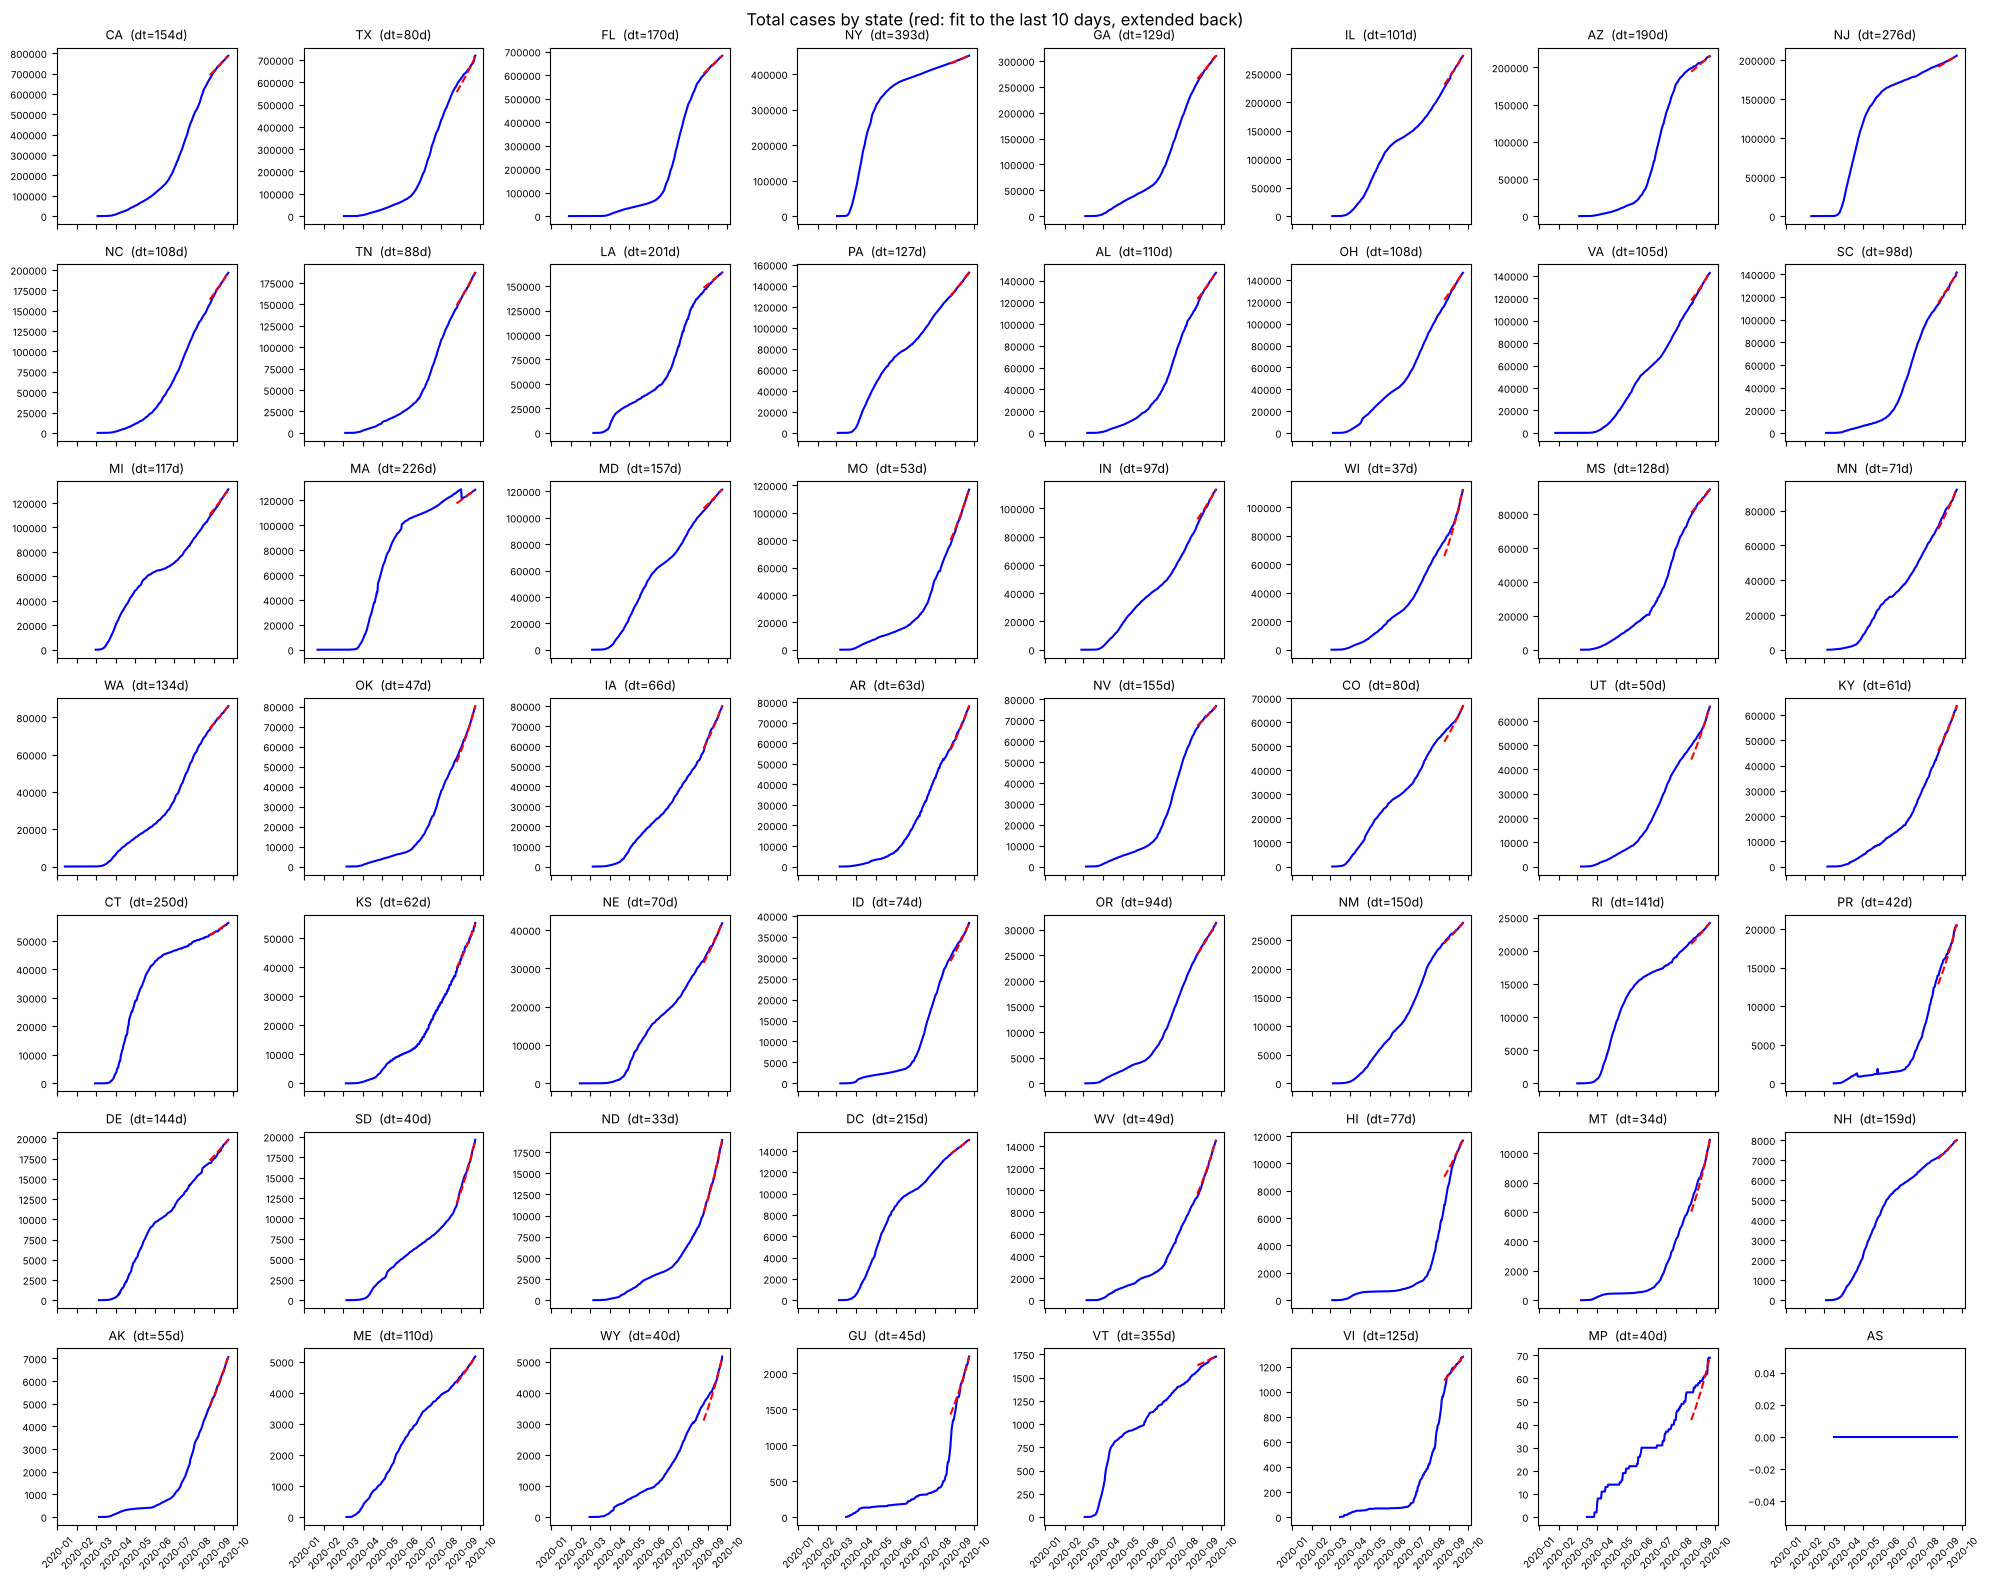

In [7]:
ncols = 8
nrows = int(np.ceil(len(states_in_order) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=[20, 2.3 * nrows], sharex=True)
for ax, s in zip(axes.flat, states_in_order):
    dfq, dt, _ = get_state_doubling_df(df, s, use_last_n_days=LAST_N_DAYS)
    ax.plot(dfq.date, dfq.positive, "b")
    ax.plot(dfq.date.iloc[-3 * LAST_N_DAYS:], dfq.exp_fit_line.iloc[-3 * LAST_N_DAYS:], "r--")
    ax.set_title(f"{s}  (dt={dt:.0f}d)" if np.isfinite(dt) else s, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.tick_params(axis="x", rotation=45)
for ax in axes.flat[len(states_in_order):]:
    ax.axis("off")
fig.suptitle("Total cases by state (red: fit to the last 10 days, extended back)")
plt.tight_layout()
plt.show()

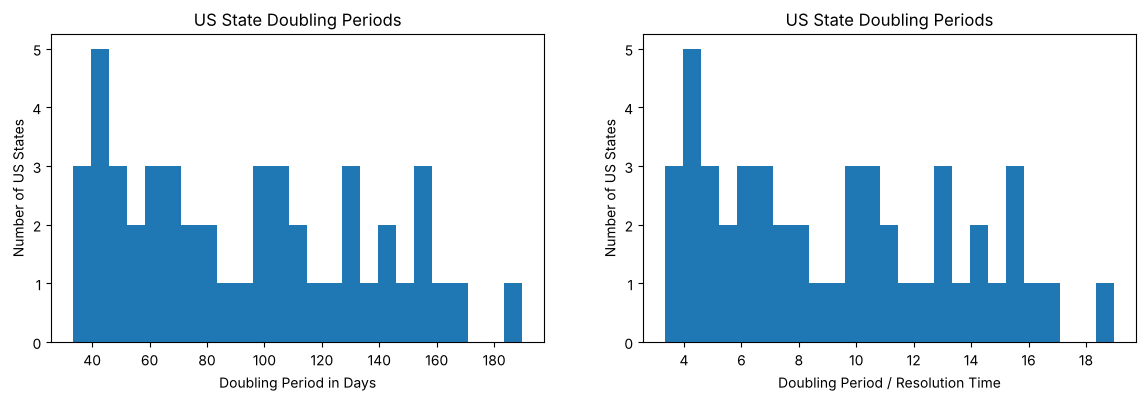

In [8]:
dp_state = states.doubling_days[(states.doubling_days > 0) & (states.doubling_days < 200)]
fig, axes = plt.subplots(1, 2, figsize=[14, 4])
axes[0].hist(dp_state, bins=25)
axes[0].set_xlabel("Doubling Period in Days")
axes[1].hist(dp_state / RESOLUTION_TIME, bins=25)
axes[1].set_xlabel("Doubling Period / Resolution Time")
for ax in axes:
    ax.set_title("US State Doubling Periods")
    ax.set_ylabel("Number of US States")
plt.show()

## Rolling doubling period: countries

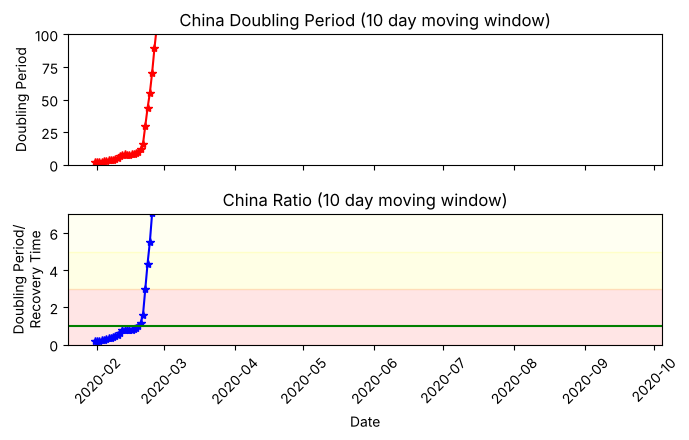

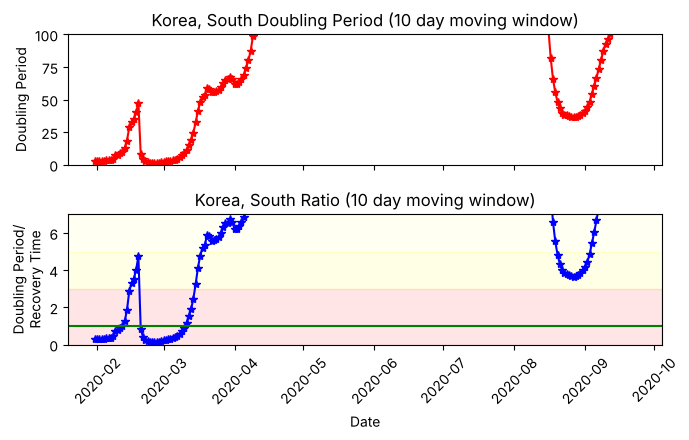

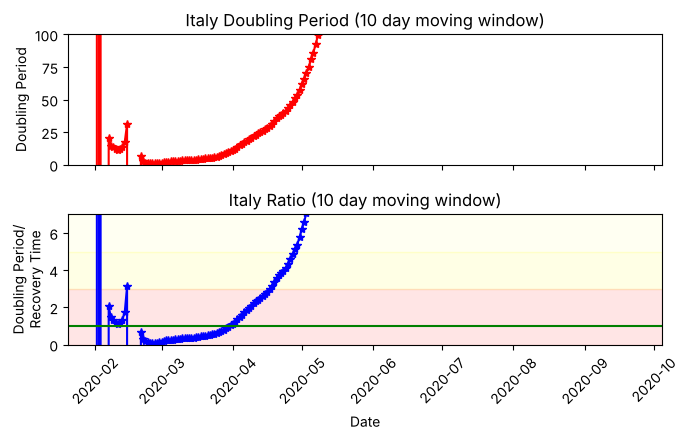

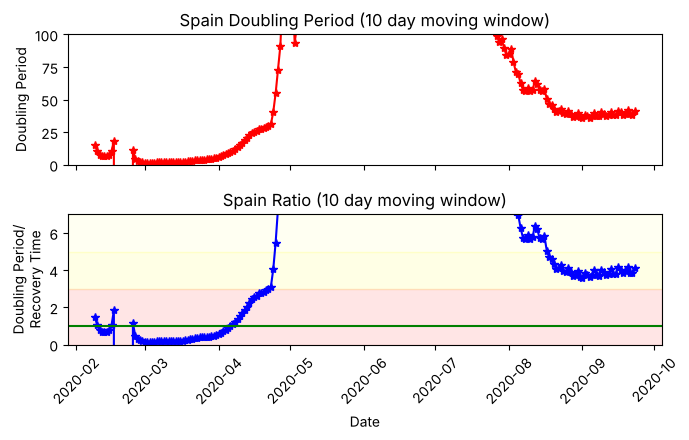

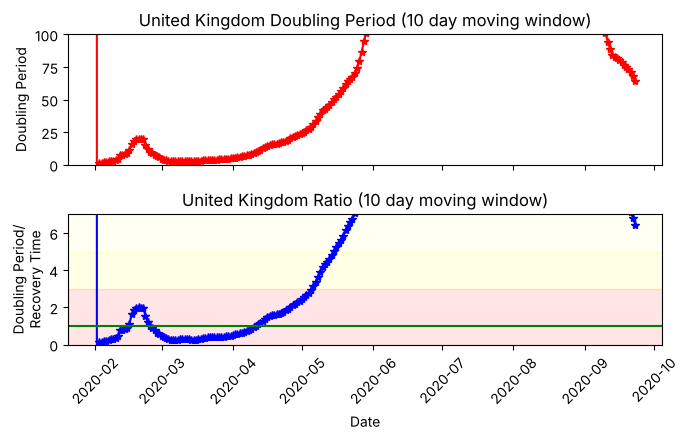

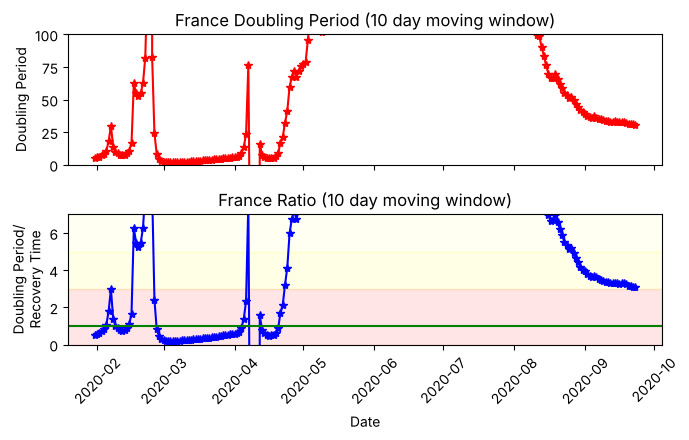

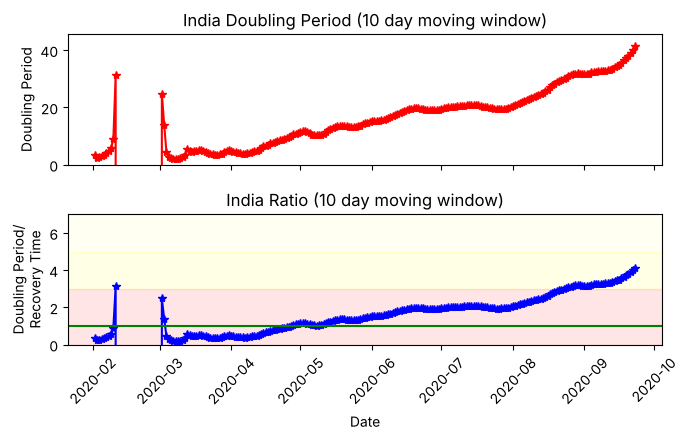

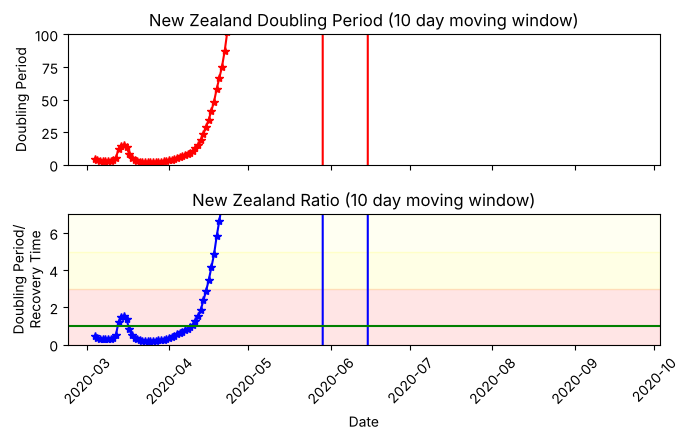

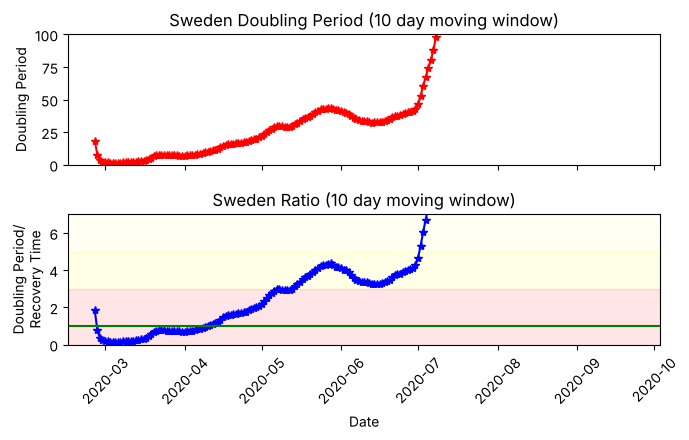

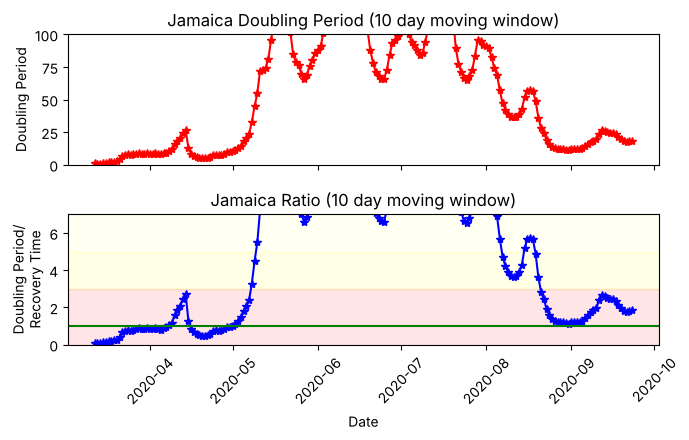

In [9]:
dfw, countries = world_daily(as_of=AS_OF)
for country in ["China", "Korea, South", "Italy", "Spain", "United Kingdom", "France", "India", "New Zealand",
                "Sweden", "Jamaica"]:
    period_factor_plot(dfw, country)

## Rolling doubling period: states

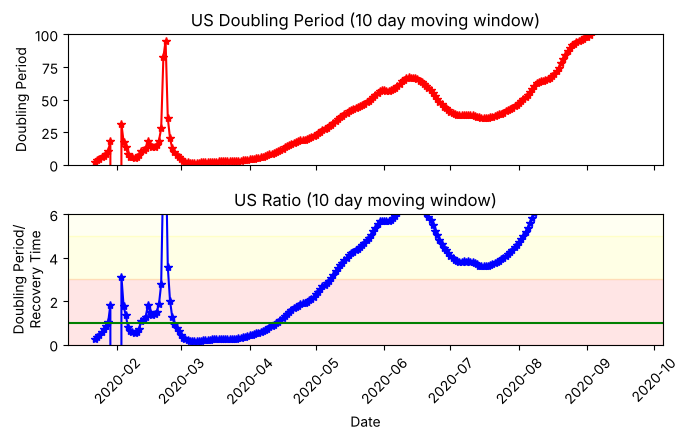

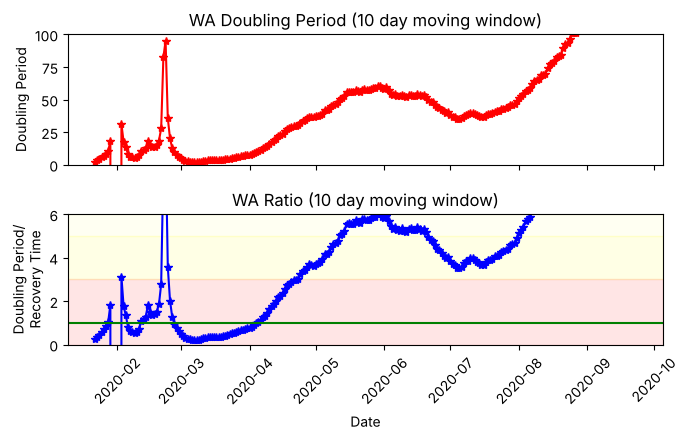

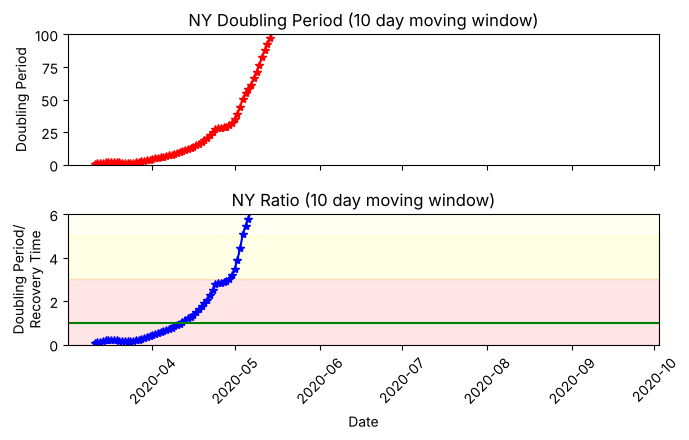

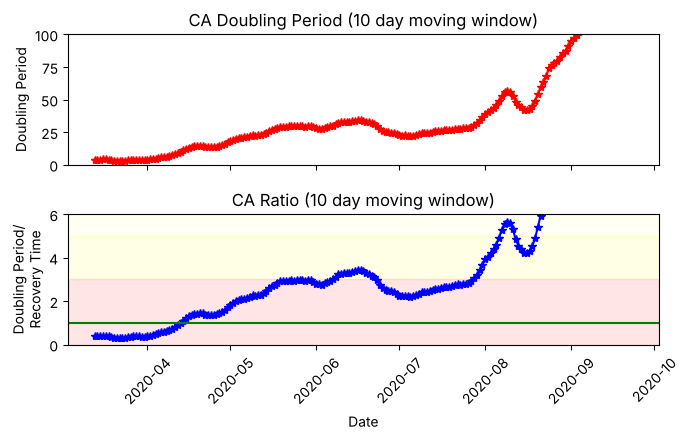

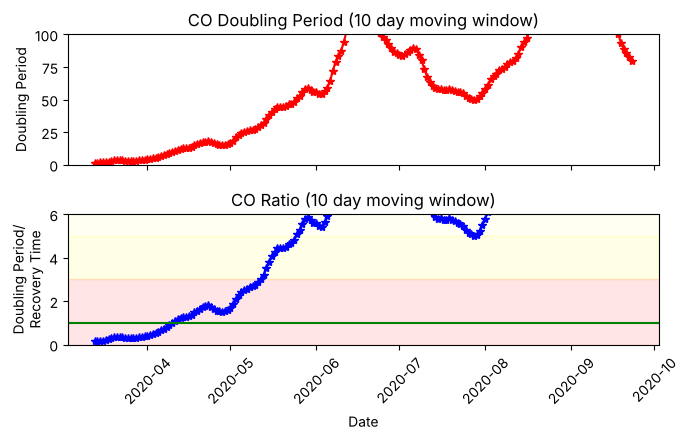

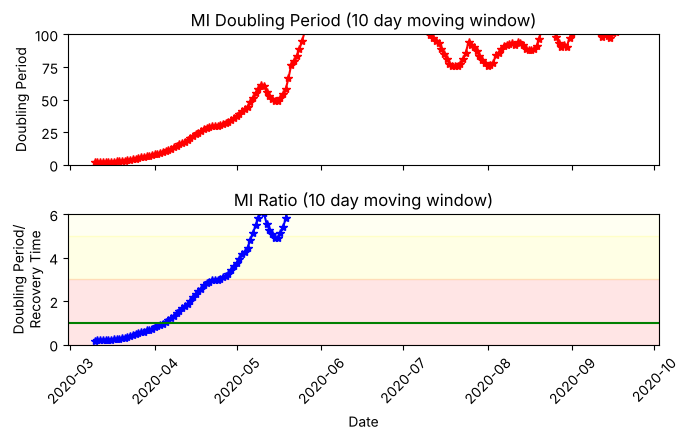

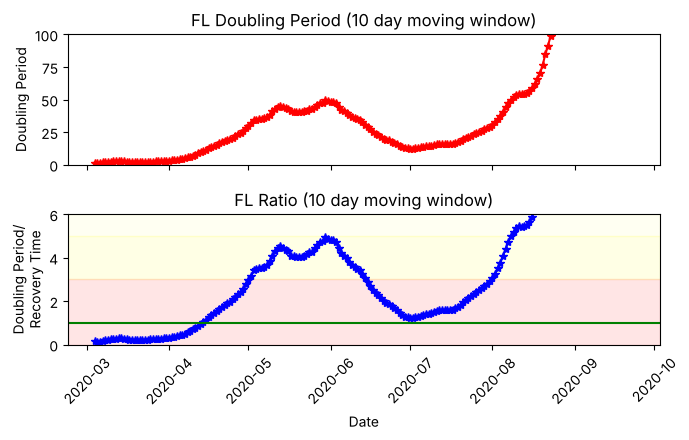

In [10]:
for s in ["*", "WA", "NY", "CA", "CO", "MI", "FL"]:
    period_factor_plot(df, s, ylimit=6)